# Actividad 03 — Algoritmos de Enjambre en ML
**Universidad Nacional del Altiplano Puno — Ingeniería de Sistemas**  
Aprendizaje de Máquina · IX Ciclo Grupo B


In [4]:
# Instalar dependencias
!pip install numpy scikit-learn matplotlib -q

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

np.random.seed(42)
print('✅ Librerías listas')

✅ Librerías listas


---
## Item C — Red Neuronal entrenada con PSO (SIN Backpropagation)

### Idea central
En lugar de calcular gradientes, cada partícula PSO es el conjunto completo de pesos y bias de la red.  
El enjambre busca en ese espacio de parámetros el mínimo de la Cross-Entropy.

### Arquitectura
```
Entrada (4) → Oculta 1 (8, ReLU) → Oculta 2 (6, ReLU) → Salida (3, Softmax)
Parámetros totales: 32 + 8 + 48 + 6 + 18 + 3 = 115
```
Cada partícula PSO = vector de **115 valores** (los pesos y bias de toda la red).

In [6]:
# ══════════════════════════════════════════════════════════════
# ITEM C — PSO Neural Network Training (SIN backpropagation)
# ══════════════════════════════════════════════════════════════

# ── DATOS ──────────────────────────────────────
data_c  = load_iris()
X_c_raw = StandardScaler().fit_transform(data_c.data)
y_c_raw = data_c.target
Y_c     = OneHotEncoder(sparse_output=False).fit_transform(y_c_raw.reshape(-1,1))

X_tr, X_te, Y_tr, Y_te, y_tr, y_te = train_test_split(
    X_c_raw, Y_c, y_c_raw, test_size=0.2, random_state=42, stratify=y_c_raw)

# ── ARQUITECTURA ───────────────────────────────
LAYERS = [4, 8, 6, 3]  # entrada → oculta1 → oculta2 → salida

DIMS = []
N_PARAMS = 0
for i in range(len(LAYERS)-1):
    nw = LAYERS[i]*LAYERS[i+1]; nb = LAYERS[i+1]
    DIMS.append((LAYERS[i], LAYERS[i+1], nw, nb))
    N_PARAMS += nw + nb

print(f'Red: {" → ".join(map(str, LAYERS))}')
print(f'Total parámetros (dimensión de cada partícula): {N_PARAMS}')

# ── ACTIVACIONES ───────────────────────────────
relu    = lambda x: np.maximum(0, x)
softmax = lambda x: (lambda e: e/e.sum(1,keepdims=True))(np.exp(x - x.max(1,keepdims=True)))

# ── DECODIFICAR PARTÍCULA → PESOS ──────────────
def decode(p):
    ws, idx = [], 0
    for (ni, no, nw, nb) in DIMS:
        ws.append((p[idx:idx+nw].reshape(ni,no), p[idx+nw:idx+nw+nb]))
        idx += nw+nb
    return ws

# ── FORWARD PASS ───────────────────────────────
def forward(X, ws):
    a = X
    for k,(W,b) in enumerate(ws):
        z = a@W+b
        a = relu(z) if k < len(ws)-1 else softmax(z)
    return a

# ── FUNCIÓN DE APTITUD (Cross-Entropy negada) ──
def aptitud_c(p):
    prob = np.clip(forward(X_tr, decode(p)), 1e-12, 1.0)
    ce   = -np.mean(np.sum(Y_tr * np.log(prob), axis=1))
    return -ce          # PSO maximiza → negamos la pérdida

def accuracy_c(p, X, y):
    return np.mean(np.argmax(forward(X, decode(p)), axis=1) == y)

print('✅ Funciones definidas')

Red: 4 → 8 → 6 → 3
Total parámetros (dimensión de cada partícula): 115
✅ Funciones definidas


In [7]:
# ══════════════════════════════════════════════════════════════
# INICIALIZACIÓN DEL ENJAMBRE
# Cada partícula = vector de 115 valores (todos los pesos de la red)
# ══════════════════════════════════════════════════════════════
N_PART = 60
MAX_IT = 200
W_IN   = 0.729   # inercia
C1_c   = 1.494   # cognitivo
C2_c   = 1.494   # social
VMAX   = 0.5

def init_particle():
    """Inicialización He por capa (óptima para ReLU)"""
    segs = []
    for (ni, no, nw, nb) in DIMS:
        segs.append(np.random.randn(nw) * np.sqrt(2.0/ni))
        segs.append(np.zeros(nb))
    return np.concatenate(segs)

pos_c   = np.array([init_particle() for _ in range(N_PART)])
vel_c   = np.random.uniform(-0.1, 0.1, (N_PART, N_PARAMS))
pb_pos_c = pos_c.copy()
pb_val_c = np.array([aptitud_c(p) for p in pos_c])
gb_idx_c = pb_val_c.argmax()
gb_pos_c = pb_pos_c[gb_idx_c].copy()
gb_val_c = pb_val_c[gb_idx_c]

print(f'Enjambre listo  — {N_PART} partículas × {N_PARAMS} dimensiones')
print(f'Loss inicial    : {-gb_val_c:.4f}')
print(f'Accuracy inicial: {accuracy_c(gb_pos_c, X_tr, y_tr):.4f}')

Enjambre listo  — 60 partículas × 115 dimensiones
Loss inicial    : 0.6931
Accuracy inicial: 0.8083


In [8]:
# ══════════════════════════════════════════════════════════════
# CICLO PRINCIPAL PSO — SIN BACKPROPAGATION
# ══════════════════════════════════════════════════════════════
hist_loss_c = []
hist_acc_tr = []
hist_acc_te = []
w_inercia   = W_IN

for it in range(MAX_IT):
    for i in range(N_PART):

        # Vectores aleatorios por dimensión
        r1 = np.random.rand(N_PARAMS)
        r2 = np.random.rand(N_PARAMS)

        # ── ACTUALIZAR VELOCIDAD (ecuación PSO) ──────
        vel_c[i] = (w_inercia * vel_c[i]
                  + C1_c * r1 * (pb_pos_c[i] - pos_c[i])
                  + C2_c * r2 * (gb_pos_c    - pos_c[i]))
        vel_c[i] = np.clip(vel_c[i], -VMAX, VMAX)

        # ── ACTUALIZAR POSICIÓN ───────────────────────
        pos_c[i] += vel_c[i]

        # ── EVALUAR APTITUD ───────────────────────────
        val = aptitud_c(pos_c[i])

        # ── ACTUALIZAR MEJOR PERSONAL (pbest) ────────
        if val > pb_val_c[i]:
            pb_val_c[i] = val
            pb_pos_c[i] = pos_c[i].copy()

            # ── ACTUALIZAR MEJOR GLOBAL (gbest) ──────
            if val > gb_val_c:
                gb_val_c = val
                gb_pos_c = pos_c[i].copy()

    # Decaer inercia (exploración → explotación)
    w_inercia = max(0.4, w_inercia * 0.995)

    loss = -gb_val_c
    acc_tr = accuracy_c(gb_pos_c, X_tr, y_tr)
    acc_te = accuracy_c(gb_pos_c, X_te, y_te)
    hist_loss_c.append(loss)
    hist_acc_tr.append(acc_tr)
    hist_acc_te.append(acc_te)

    if it % 25 == 0 or it == MAX_IT-1:
        print(f'Iter {it:4d} | Loss: {loss:.4f} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}')

print(f'\n✅ Entrenamiento PSO completado — SIN backpropagation')

Iter    0 | Loss: 0.6931 | Train: 0.8083 | Test: 0.8000
Iter   25 | Loss: 0.0375 | Train: 0.9833 | Test: 0.9667
Iter   50 | Loss: 0.0339 | Train: 0.9833 | Test: 0.9667
Iter   75 | Loss: 0.0331 | Train: 0.9833 | Test: 0.9667
Iter  100 | Loss: 0.0328 | Train: 0.9833 | Test: 0.9667
Iter  125 | Loss: 0.0326 | Train: 0.9833 | Test: 0.9667
Iter  150 | Loss: 0.0313 | Train: 0.9833 | Test: 1.0000
Iter  175 | Loss: 0.0286 | Train: 0.9833 | Test: 0.9667
Iter  199 | Loss: 0.0237 | Train: 0.9917 | Test: 0.9667

✅ Entrenamiento PSO completado — SIN backpropagation


In [9]:
# ── RESULTADOS FINALES ─────────────────────────
print('='*50)
print(' RESULTADOS FINALES — Item C')
print('='*50)
print(f'  Loss final        : {-gb_val_c:.4f}')
print(f'  Accuracy Train    : {accuracy_c(gb_pos_c, X_tr, y_tr):.4f}')
print(f'  Accuracy Test     : {accuracy_c(gb_pos_c, X_te, y_te):.4f}')
print(f'  Backpropagation   : ❌ NO se usó')
print()

y_pred = np.argmax(forward(X_te, decode(gb_pos_c)), axis=1)
print(classification_report(y_te, y_pred, target_names=data_c.target_names))

 RESULTADOS FINALES — Item C
  Loss final        : 0.0237
  Accuracy Train    : 0.9917
  Accuracy Test     : 0.9667
  Backpropagation   : ❌ NO se usó

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



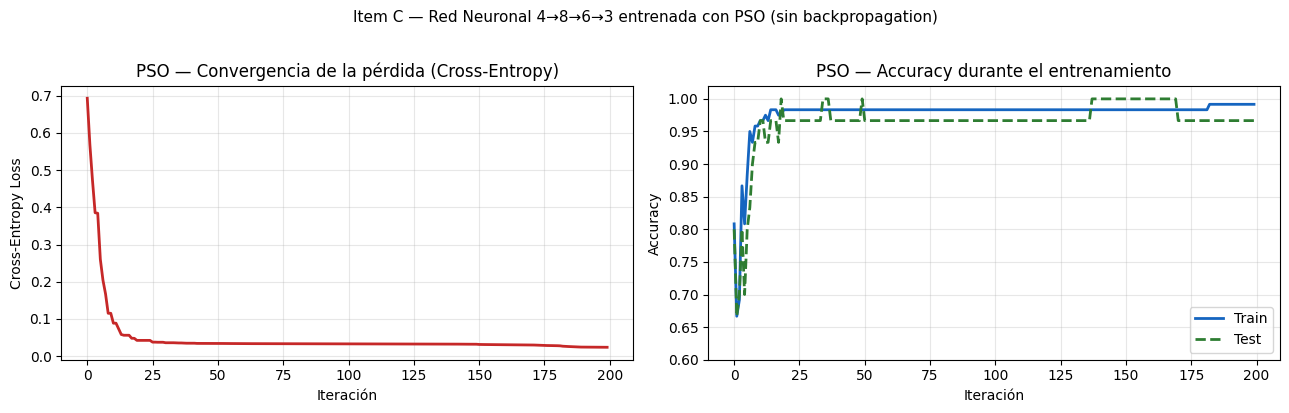

In [10]:
# ── GRÁFICAS ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_loss_c, color='#c62828', linewidth=2)
axes[0].set_title('PSO — Convergencia de la pérdida (Cross-Entropy)', fontsize=12)
axes[0].set_xlabel('Iteración'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(hist_acc_tr, label='Train', color='#1565c0', linewidth=2)
axes[1].plot(hist_acc_te, label='Test',  color='#2e7d32', linewidth=2, linestyle='--')
axes[1].set_title('PSO — Accuracy durante el entrenamiento', fontsize=12)
axes[1].set_xlabel('Iteración'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.6, 1.02])

plt.suptitle('Item C — Red Neuronal 4→8→6→3 entrenada con PSO (sin backpropagation)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

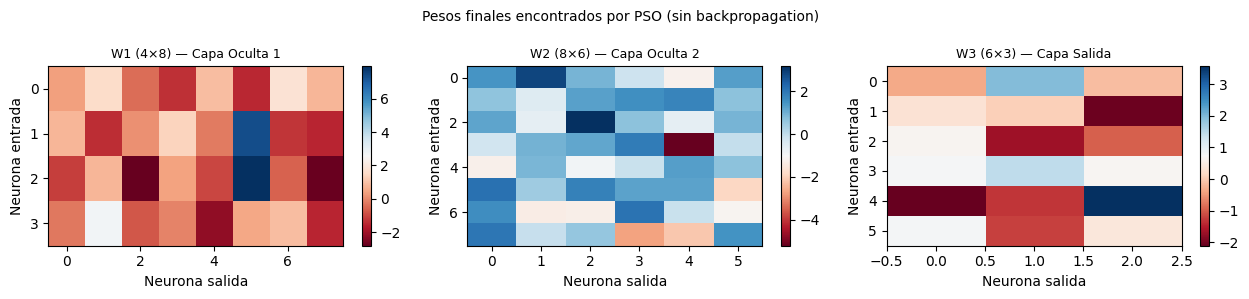

In [11]:
# ── VISUALIZAR PESOS FINALES ───────────────────
ws_final = decode(gb_pos_c)
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
titulos = ['W1 (4×8) — Capa Oculta 1', 'W2 (8×6) — Capa Oculta 2', 'W3 (6×3) — Capa Salida']
for k, (ax, (W, b), tit) in enumerate(zip(axes, ws_final, titulos)):
    im = ax.imshow(W, cmap='RdBu', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title(tit, fontsize=9)
    ax.set_xlabel('Neurona salida'); ax.set_ylabel('Neurona entrada')
plt.suptitle('Pesos finales encontrados por PSO (sin backpropagation)', fontsize=10)
plt.tight_layout(); plt.show()